In [1]:
import matplotlib
import qiskit
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

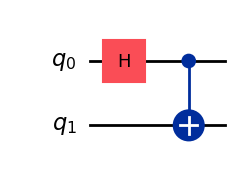

In [2]:

qc=QuantumCircuit(2)

qc.h(0)
qc.cx(0,1)
qc.draw(output='mpl')

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_cloud" , token="MR35WnkFS0fROx6A0MBaqlTBe6Zlr-Qytg4omZaqiT0Z")

qiskit_runtime_service._discover_account:WARNING:2026-05-26 17:33:23,582: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-26 17:33:31,118: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [6]:
from qiskit.quantum_info import Pauli

ZZ=Pauli('ZZ')
ZI=Pauli('ZI')
IZ=Pauli('IZ')
XX=Pauli('XX')
XI=Pauli('XI')
IX=Pauli('IX')

observables=[ZZ,ZI,IZ,XX,XI,IX]

In [9]:
from qiskit_aer.primitives import Estimator
estimator = Estimator()
job = estimator.run([qc]*len(observables), observables)
job.result()

EstimatorResult(values=array([ 1.        , -0.04882812, -0.04882812,  1.        ,  0.04101562,
        0.04101562]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0030151, 'sample_measure_time': 0.0005473, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 24351, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 20, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9976158142089844, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0030151, 'sample_measure_time': 0.0005

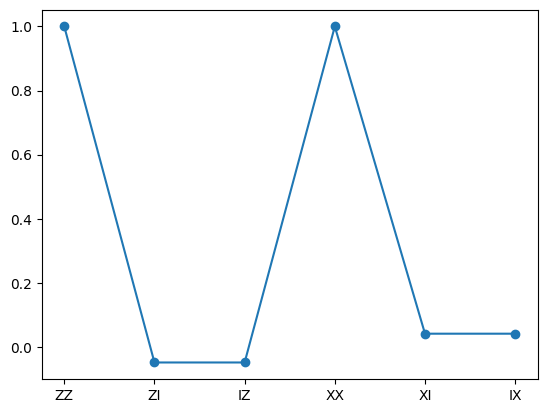

In [13]:
import matplotlib.pyplot as plt
data=['ZZ','ZI','IZ','XX','XI','IX']
values=job.result().values
plt.plot(data,values,'-o')